# Exercise Set 3, Exercise 1
## Logistic regression of sex given weight and height

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import statsmodels.api as sm
# statsmodels uses patsy for describing statistical models as in R, e.g.
# y ~ x + a + b + a:b
# and building design matrices

In [4]:
df = pd.read_csv("kgr.gew.geschl.tbl", sep = '\t')
df["sex"] = df["Sex/Gender"].map({"Female" : 0, "Male": 1})
print(df.head())

   Height  Weight Sex/Gender  sex
0     173     160     Female    0
1     163     170     Female    0
2     163     130       Male    1
3     163     180     Female    0
4     170     145     Female    0


In [11]:
# linear regression model
model = sm.formula.glm("sex ~ Height + Weight", # formula has 3 coefficients as bias is implicit
                       family = sm.families.Binomial(), data = df)
results = model.fit(start_params = (-5, 0.01, 0.01), maxiter = 100) # defaults are fine as well

In [12]:
results.summary()

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    sex   No. Observations:                   42
Model:                            GLM   Df Residuals:                       39
Model Family:                Binomial   Df Model:                            2
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -14.539
Date:                Wed, 13 Nov 2019   Deviance:                       29.077
Time:                        10:21:17   Pearson chi2:                     29.6
No. Iterations:                     6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -46.6276     15.377     -3.032      0.0

### Make predictions with the trained parameters

In [22]:
theta = results.params.values
theta

theta =  [-4.66275856e+01  2.64451764e-01  1.21719076e-02]


In [23]:
t = model.predict(theta)
t

array([0.74461115, 0.18958274, 0.12569181, 0.20899324, 0.52351787,
       0.98305875, 0.83857536, 0.16892361, 0.97913269, 0.9998461 ,
       0.7537591 , 0.52821331, 0.02200806, 0.02350922, 0.36436193,
       0.30485936, 0.15496721, 0.61284767, 0.35594741, 0.97758713,
       0.98433611, 0.94979204, 0.98952044, 0.88086545, 0.98057379,
       0.80477339, 0.98333384, 0.9602089 , 0.95175873, 0.99602492,
       0.92922942, 0.81415826, 0.9988224 , 0.79503391, 0.98607638,
       0.98907554, 0.40759825, 0.24525486, 0.99156494, 0.39298965,
       0.79897238, 0.31004267])

In [49]:
leastLikelyMale = t.argmin()
mostLikelyMale = t.argmax()
minMaleProb = t[leastLikelyMale]
maxMaleProb = t[mostLikelyMale]

print ("most likely to be male: index =", mostLikelyMale, ", probability=",
       maxMaleProb, "\n", df.loc[mostLikelyMale])
print ("\nleast likely to be male: index =", leastLikelyMale, ", probability=",
       minMaleProb, "\n", df.loc[leastLikelyMale])

most likely to be male: index = 9 , probability= 0.9998460951275511 
 Height         201
Weight         185
Sex/Gender    Male
sex              1
Name: 9, dtype: object

least likely to be male: index = 12 , probability= 0.022008062429152844 
 Height           157
Weight           108
Sex/Gender    Female
sex                0
Name: 12, dtype: object


### Plot decision boundary


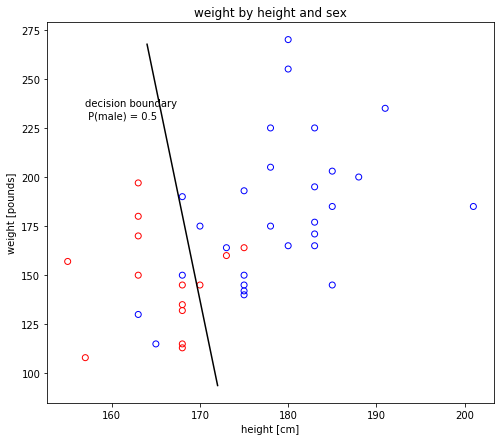

In [48]:
# first make the original scatter plot
fig, ax = plt.subplots(figsize = (8, 7))
ax.scatter(df['Height'].values, df['Weight'].values,
    edgecolors = np.array(["red", "blue"])[df.sex], # sex colors: red, blue
    facecolors = 'none')

ax.set_xlabel('height [cm]')
ax.set_ylabel('weight [pounds]')
ax.set_title('weight by height and sex')

# decision boundary P(male) = 0.5
prob_thres = 0.5

# solve
# sigma(theta[0] + theta[1] x_1 + theta[2] x_2) = prob_thresh
# for x_2

def logit(p):
    return math.log(p/(1-p))

thresh = logit(prob_thres)
intercept, slope = (thresh - theta[0], - theta[1]) / theta[2]

xs = [164, 172]
ys = [intercept + slope * x for x in xs]
ax.plot(xs, ys, "k")
ax.text(157, 230, "decision boundary\n P(male) = " + str(prob_thres));